# Análisis de los resultados

In [37]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
%matplotlib inline

RESULTS_DIR = Path('..') / 'results'
DEFAULT_WORKERS = [1, 2, 4, 8, 16, 32]
DEFAULT_BUFFERS = [5, 20, 50, 100]

METRICS = [
    ('trimmed_mean_time_ms', 'Tiempo medio recortado (ms)'),
    ('trimmed_max_rss_mb', 'RSS máximo recortado (MB)'),
    ('trimmed_avg_cpu_percent', 'CPU promedio recortada (%)'),
]

In [38]:
rows = []

for path in sorted(RESULTS_DIR.glob('benchmark_*.json')):
    with path.open() as f:
        data = json.load(f)

    params = data.get('execution_params', {})
    summary = data.get('summary', {})

    rows.append({
        'file': path.name,
        'timestamp': data.get('timestamp'),
        'mode': params.get('mode'),
        'workers': params.get('workers'),
        'buffer': params.get('record_buffer_multiplier'),
        'trimmed_mean_time_ms': summary.get('trimmed_mean_time_ms'),
        'trimmed_max_rss_mb': summary.get('trimmed_max_rss_mb'),
        'trimmed_avg_cpu_percent': summary.get('trimmed_avg_cpu_percent'),
    })

df = pd.DataFrame(rows)

numeric_columns = ['workers', 'buffer'] + [metric for metric, _ in METRICS]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='raise')

print(f'Loaded {len(df)} benchmark reports from {len(rows)} JSON files')
print(f"Modes: {sorted(df['mode'].dropna().unique())}")
display(df.head(10))

Loaded 50 benchmark reports from 50 JSON files
Modes: ['concurrent', 'sequential']


,file,timestamp,mode,workers,buffer,trimmed_mean_time_ms,trimmed_max_rss_mb,trimmed_avg_cpu_percent
0,benchmark_20260429_120408.json,2026-04-29T12:04:08-05:00,concurrent,1,5,920.977872,479.756510,162.690495
1,benchmark_20260429_120423.json,2026-04-29T12:04:23-05:00,concurrent,1,20,732.283583,488.042969,187.110005
2,benchmark_20260429_120436.json,2026-04-29T12:04:36-05:00,concurrent,1,50,685.099993,483.425781,195.939792
3,benchmark_20260429_120450.json,2026-04-29T12:04:50-05:00,concurrent,1,100,679.908910,485.044271,196.463743
4,benchmark_20260429_120508.json,2026-04-29T12:05:08-05:00,concurrent,2,5,860.522681,470.226562,201.511080
5,benchmark_20260429_120525.json,2026-04-29T12:05:25-05:00,concurrent,2,20,840.346951,480.902344,205.792389
6,benchmark_20260429_120542.json,2026-04-29T12:05:42-05:00,concurrent,2,50,836.867017,469.375000,205.862234
7,benchmark_20260429_120559.json,2026-04-29T12:05:59-05:00,concurrent,2,100,837.827653,488.747396,206.065271
8,benchmark_20260429_120616.json,2026-04-29T12:06:16-05:00,concurrent,4,5,849.885045,481.473958,204.959536
9,benchmark_20260429_120633.json,2026-04-29T12:06:33-05:00,concurrent,4,20,839.048983,477.433594,205.444672


In [39]:
sequential = df[df['mode'] == 'sequential'].copy()
concurrent = df[df['mode'] == 'concurrent'].copy()

baseline = sequential[[metric for metric, _ in METRICS]].mean()

config_agg = (
    concurrent
    .groupby(['workers', 'buffer'], as_index=False)
    .agg(
        reports=('file', 'count'),
        trimmed_mean_time_ms=('trimmed_mean_time_ms', 'mean'),
        trimmed_max_rss_mb=('trimmed_max_rss_mb', 'mean'),
        trimmed_avg_cpu_percent=('trimmed_avg_cpu_percent', 'mean'),
    )
    .sort_values(['buffer', 'workers'])
    .reset_index(drop=True)
)

for metric, _ in METRICS:
    config_agg[f'pct_change_{metric}'] = ((config_agg[metric] - baseline[metric]) / baseline[metric]) * 100

print(f'Aggregated into {len(config_agg)} configurations')
display(config_agg.head(12))

Aggregated into 24 configurations


,workers,buffer,reports,trimmed_mean_time_ms,trimmed_max_rss_mb,trimmed_avg_cpu_percent,pct_change_trimmed_mean_time_ms,pct_change_trimmed_max_rss_mb,pct_change_trimmed_avg_cpu_percent
0,1,5,2,1408.298203,481.394368,179.510417,11.913778,-1.559669,30.382185
1,2,5,2,1340.695861,475.772135,235.588655,6.541597,-2.709359,71.112986
2,4,5,2,1229.475385,475.540202,236.276037,-2.296804,-2.756787,71.612247
3,8,5,2,1177.937614,477.141764,250.065406,-6.392376,-2.429284,81.627755
4,16,5,2,1197.682041,479.471029,244.343508,-4.823338,-1.952973,77.471820
5,32,5,2,1175.466461,480.161621,235.974896,-6.588752,-1.811753,71.393522
6,1,20,2,1053.063437,483.077474,203.322162,-16.315801,-1.215491,47.677155
7,2,20,2,1560.567434,483.178060,232.226889,24.014216,-1.194922,68.671265
8,4,20,2,1174.957904,479.082845,245.220891,-6.629166,-2.032352,78.109082
9,8,20,2,1170.836318,480.797038,244.235133,-6.956697,-1.681817,77.393105


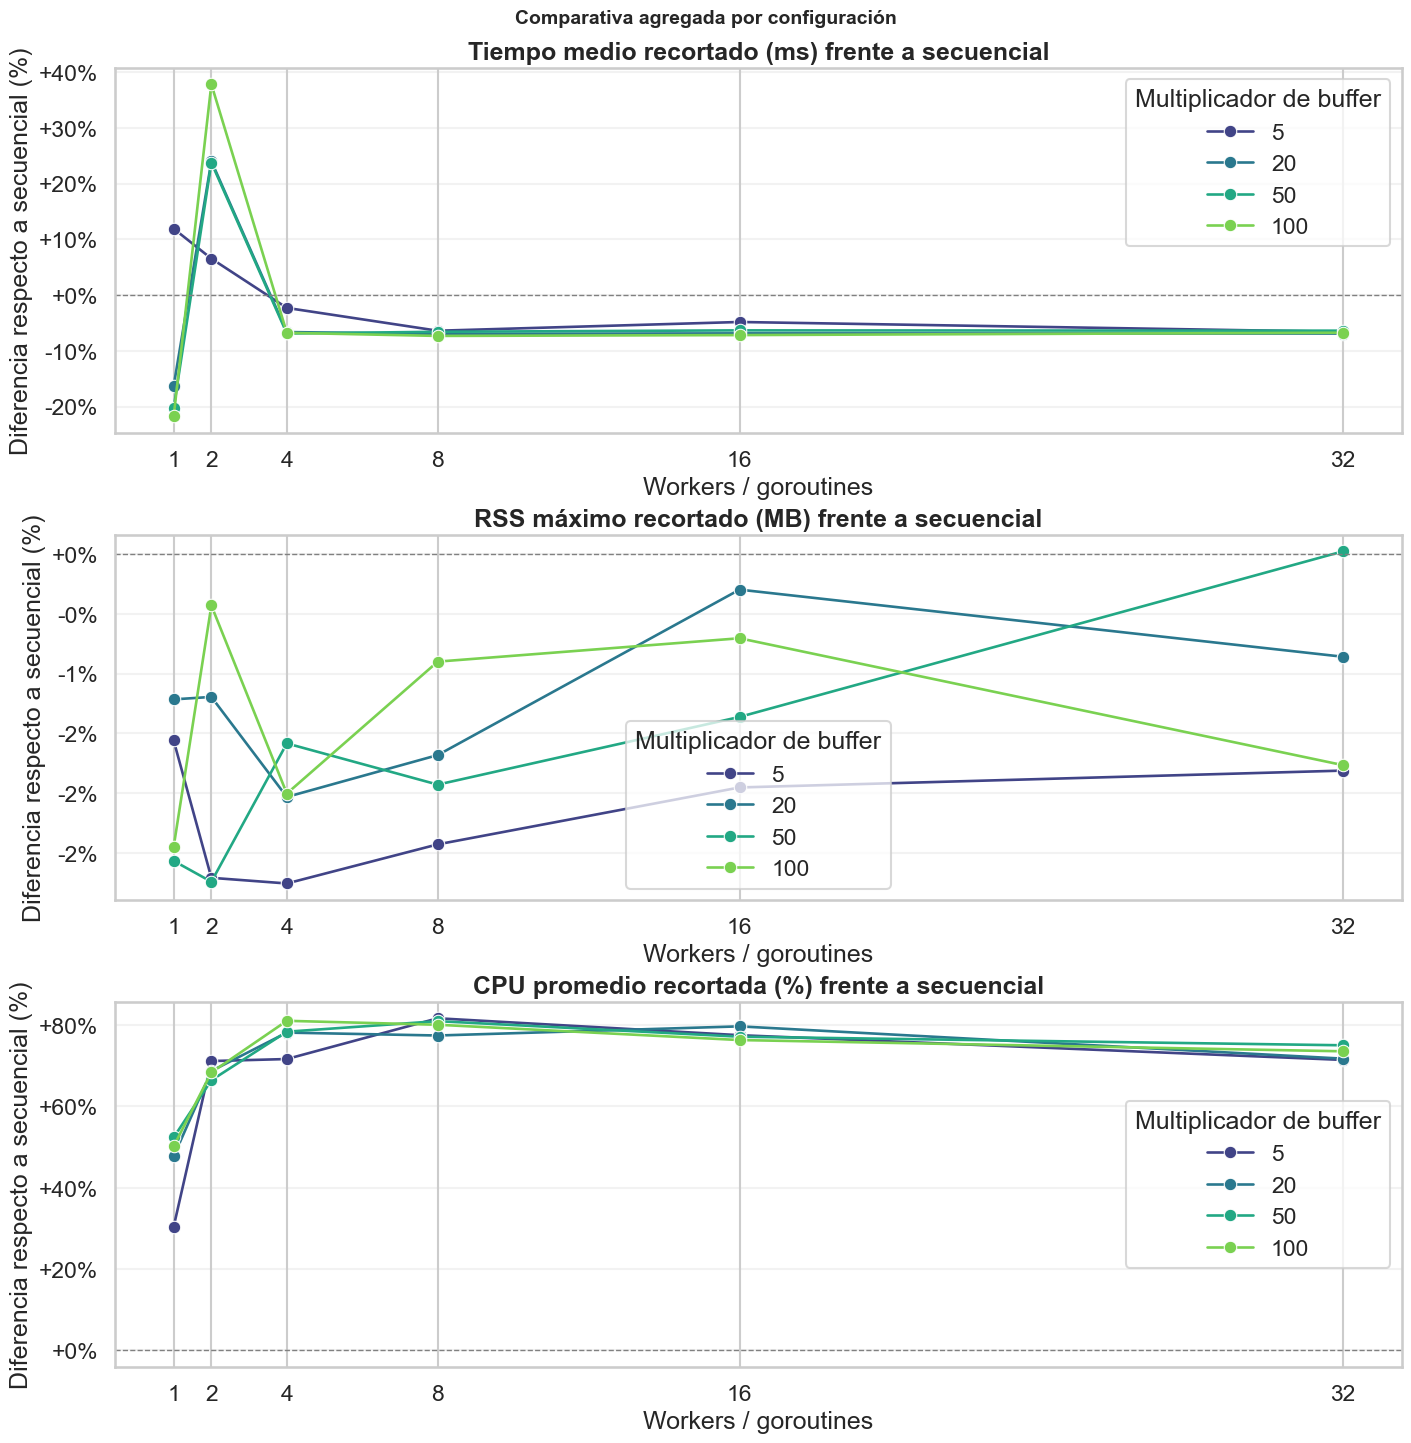

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), constrained_layout=True)
buffer_palette = dict(zip(DEFAULT_BUFFERS, sns.color_palette('viridis', n_colors=len(DEFAULT_BUFFERS))))

for ax, (metric, title) in zip(axes, METRICS):
    pct_col = f'pct_change_{metric}'

    sns.lineplot(
        data=config_agg,
        x='workers',
        y=pct_col,
        hue='buffer',
        hue_order=DEFAULT_BUFFERS,
        palette=buffer_palette,
        marker='o',
        linewidth=1.9,
        ax=ax,
    )

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{title} frente a secuencial', fontweight='bold')
    ax.set_xlabel('Workers / goroutines')
    ax.set_ylabel('Diferencia respecto a secuencial (%)')
    ax.set_xticks(DEFAULT_WORKERS)
    ax.set_xticklabels([str(worker) for worker in DEFAULT_WORKERS])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:+.0f}%'))
    ax.grid(True, axis='y', alpha=0.25)

    legend = ax.legend(title='Multiplicador de buffer', frameon=True)
    legend.get_frame().set_alpha(0.75)

plt.suptitle('Comparativa agregada por configuración', fontsize=14, fontweight='bold', y=1.02)
plt.show()


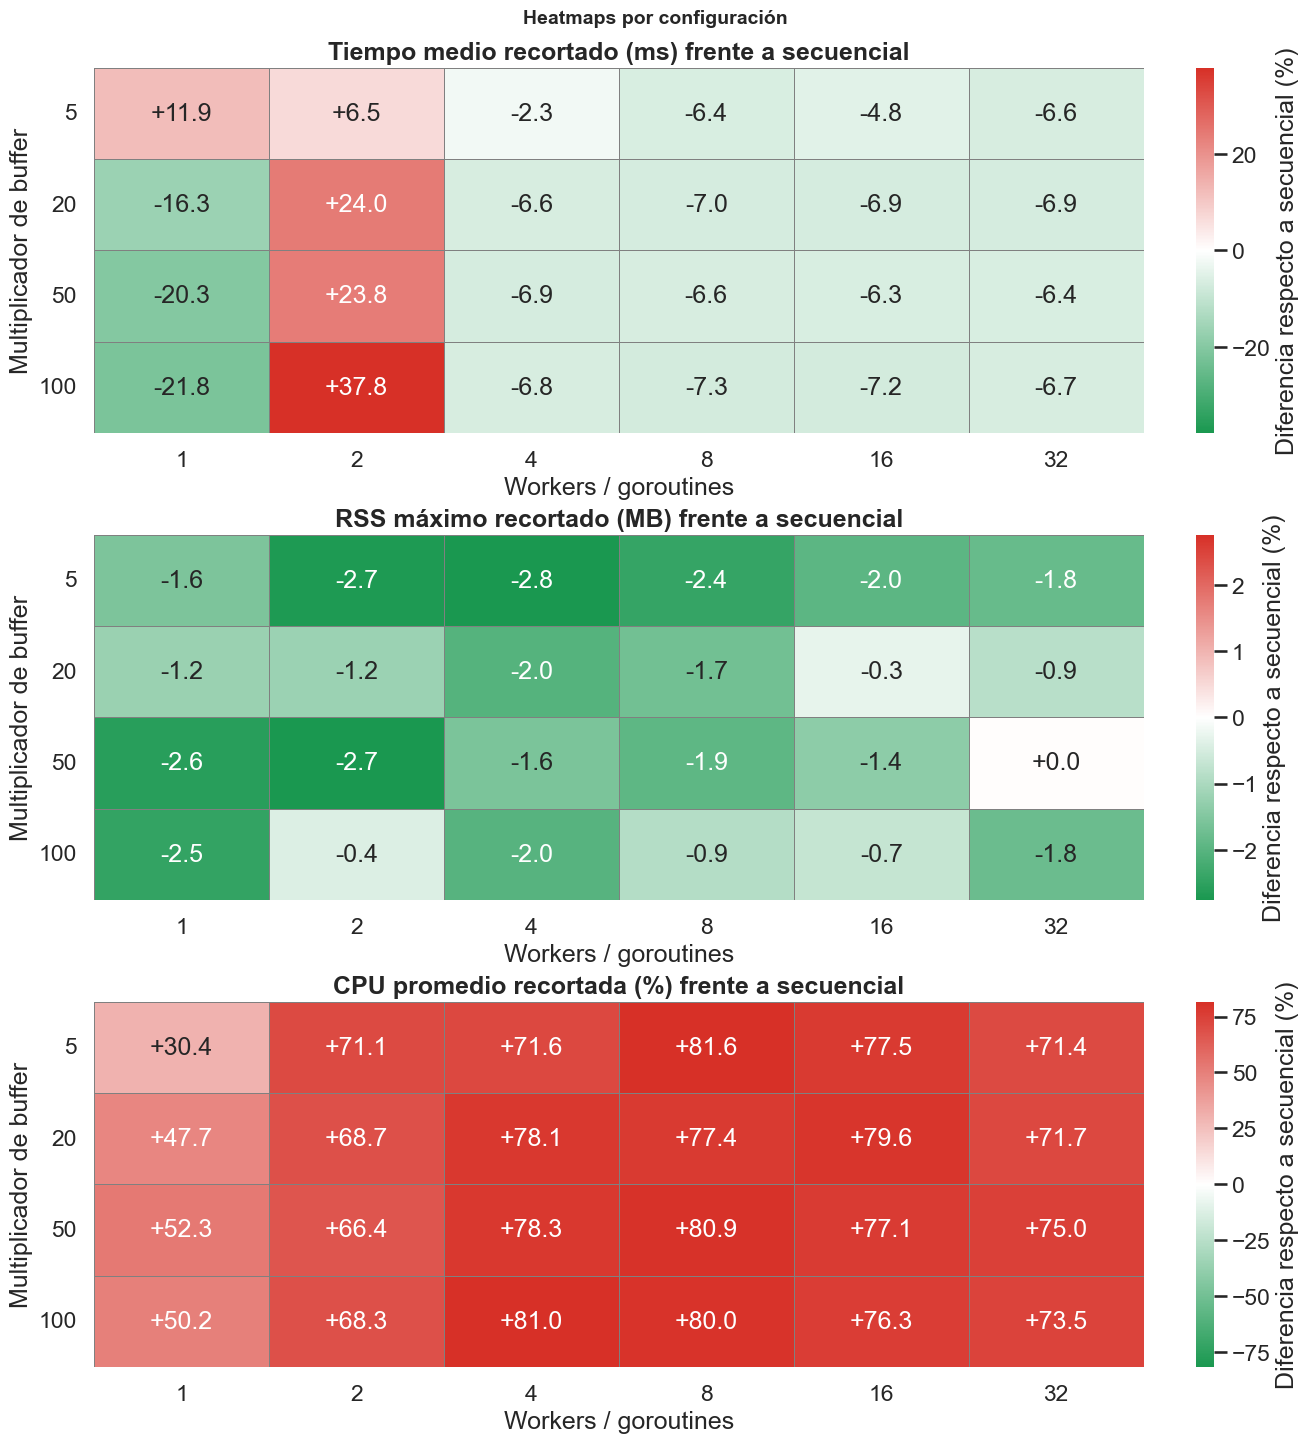

In [41]:
def make_heatmap_matrix(frame, metric_col):
    pivot = frame.pivot_table(
        index='buffer',
        columns='workers',
        values=metric_col,
        aggfunc='mean',
    )
    return pivot.reindex(index=DEFAULT_BUFFERS, columns=DEFAULT_WORKERS)

green_white_red = LinearSegmentedColormap.from_list(
    'green_white_red',
    ['#1a9850', '#ffffff', '#d73027'],
    N=256,
)

fig, axes = plt.subplots(3, 1, figsize=(13, 14), constrained_layout=True)

for ax, (metric, title) in zip(axes, METRICS):
    pct_col = f'pct_change_{metric}'
    matrix = make_heatmap_matrix(config_agg, pct_col)
    vmax = max(np.nanmax(np.abs(matrix.values)), 1.0)

    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt='+.1f',
        center=0,
        cmap=green_white_red,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={'label': 'Diferencia respecto a secuencial (%)'},
        linewidths=0.5,
        linecolor='gray',
    )

    ax.set_title(f'{title} frente a secuencial', fontweight='bold')
    ax.set_xlabel('Workers / goroutines')
    ax.set_ylabel('Multiplicador de buffer')
    ax.set_xticklabels([str(worker) for worker in DEFAULT_WORKERS], rotation=0)
    ax.set_yticklabels([str(buffer) for buffer in DEFAULT_BUFFERS], rotation=0)

plt.suptitle('Heatmaps por configuración', fontsize=14, fontweight='bold', y=1.02)
plt.show()
